## ============================================================
## HIERARCHICAL CLUSTERING - MALL CUSTOMERS DATASET
## ============================================================

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import AgglomerativeClustering

In [3]:
df = pd.read_csv("Mall_Customers.csv")

print(df.head())

print(df.info())

print(df.isnull().sum())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None
CustomerID                0
Genre                     0
Age              

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [7]:
linked = linkage(
    X_scaled, method='ward')
print(linked)

[[6.50000000e+01 6.80000000e+01 0.00000000e+00 2.00000000e+00]
 [4.80000000e+01 4.90000000e+01 0.00000000e+00 2.00000000e+00]
 [1.56000000e+02 1.58000000e+02 0.00000000e+00 2.00000000e+00]
 [1.29000000e+02 1.31000000e+02 0.00000000e+00 2.00000000e+00]
 [1.70000000e+02 1.74000000e+02 3.81694292e-02 2.00000000e+00]
 [5.10000000e+01 5.30000000e+01 3.81694292e-02 2.00000000e+00]
 [9.20000000e+01 9.90000000e+01 3.81694292e-02 2.00000000e+00]
 [1.01000000e+02 1.09000000e+02 3.81694292e-02 2.00000000e+00]
 [9.40000000e+01 9.80000000e+01 3.81694292e-02 2.00000000e+00]
 [1.07000000e+02 1.13000000e+02 3.81694292e-02 2.00000000e+00]
 [2.10000000e+01 2.30000000e+01 3.81694292e-02 2.00000000e+00]
 [1.50000000e+02 1.54000000e+02 3.88215607e-02 2.00000000e+00]
 [1.51000000e+02 1.55000000e+02 3.88215607e-02 2.00000000e+00]
 [6.00000000e+01 6.10000000e+01 3.88215607e-02 2.00000000e+00]
 [1.03000000e+02 1.04000000e+02 3.88215607e-02 2.00000000e+00]
 [1.19000000e+02 1.20000000e+02 3.88215607e-02 2.000000

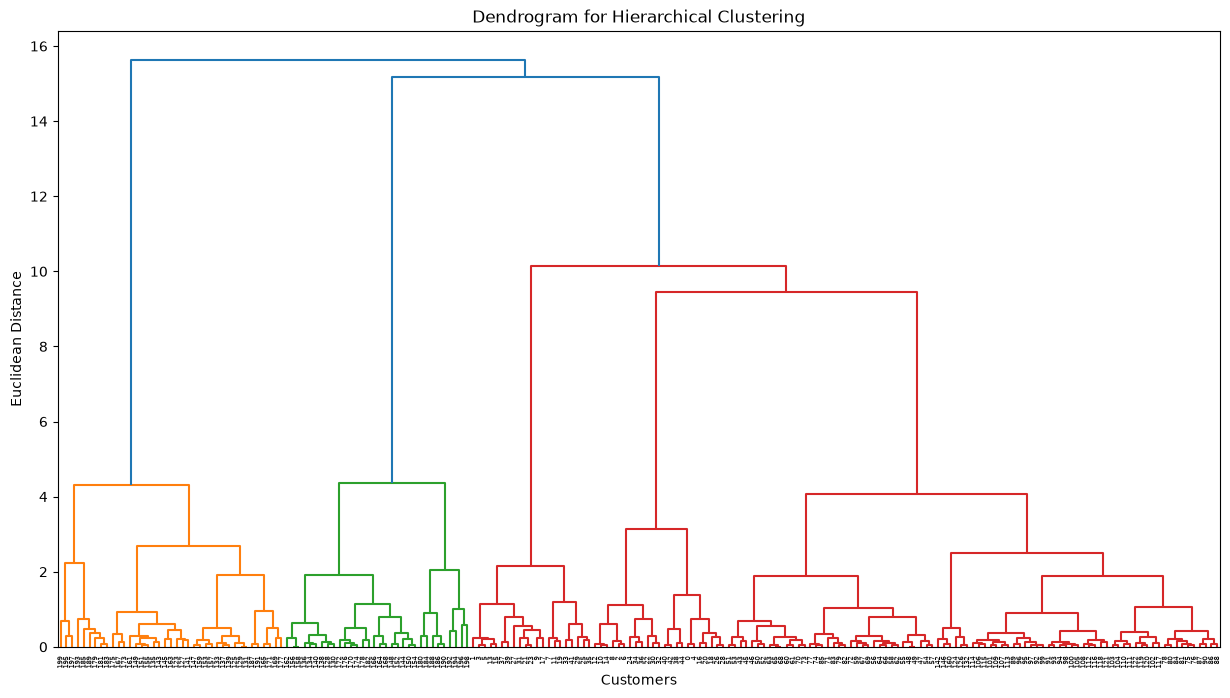

In [8]:
plt.figure(figsize=(15,8))

dendrogram(linked)

plt.title(
    "Dendrogram for Hierarchical Clustering")

plt.xlabel("Customers")

plt.ylabel("Euclidean Distance")

plt.show()

In [9]:
hc = AgglomerativeClustering(
    n_clusters = 3,
    metric = 'euclidean',
    linkage='ward'
)

clusters = hc.fit_predict(X_scaled)

print(clusters)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 0 1
 2 1 2 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


In [10]:
df['Cluster'] = clusters

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  


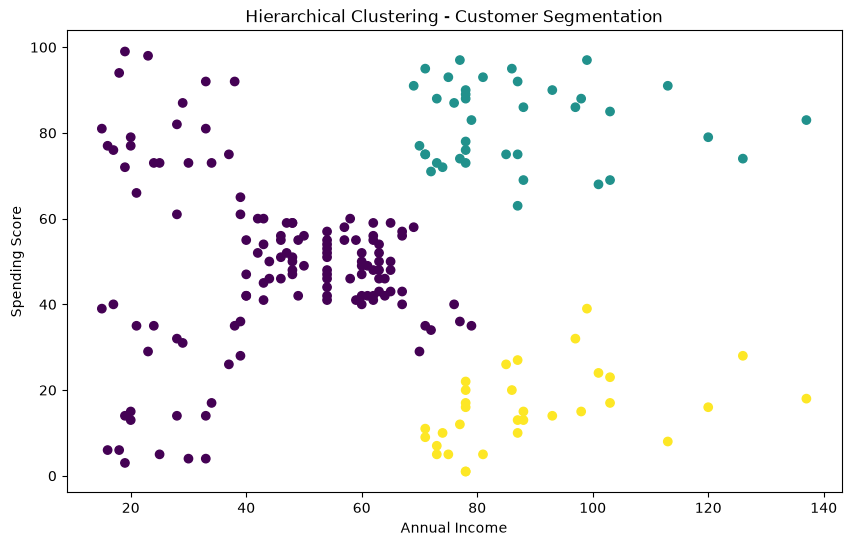

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel('Annual Income')

plt.ylabel('Spending Score')

plt.title('Hierarchical Clustering - Customer Segmentation')

plt.show()

In [12]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)' ,
                                         'Spending Score (1-100)']].mean()
print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 45.550388               49.131783
1                 86.538462               82.128205
2                 89.406250               15.593750


In [14]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,0.515000
std,57.879185,13.969007,26.264721,25.823522,0.756729
min,1.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,28.750000,41.500000,34.750000,0.000000
50%,100.500000,36.000000,61.500000,50.000000,0.000000
75%,150.250000,49.000000,78.000000,73.000000,1.000000
max,200.000000,70.000000,137.000000,99.000000,2.000000


In [15]:
hc = AgglomerativeClustering(
    n_clusters = 5,
    metric = 'euclidean',
    linkage='ward'
)

clusters = hc.fit_predict(X_scaled)

print(clusters)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 2 4 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 2 1 0 1 0 1 2 1 0 1 0 1 0 1 0 1 2 1 0 1 2 1
 0 1 0 1 0 1 0 1 0 1 0 1 2 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]


In [16]:
df['Cluster'] = clusters

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


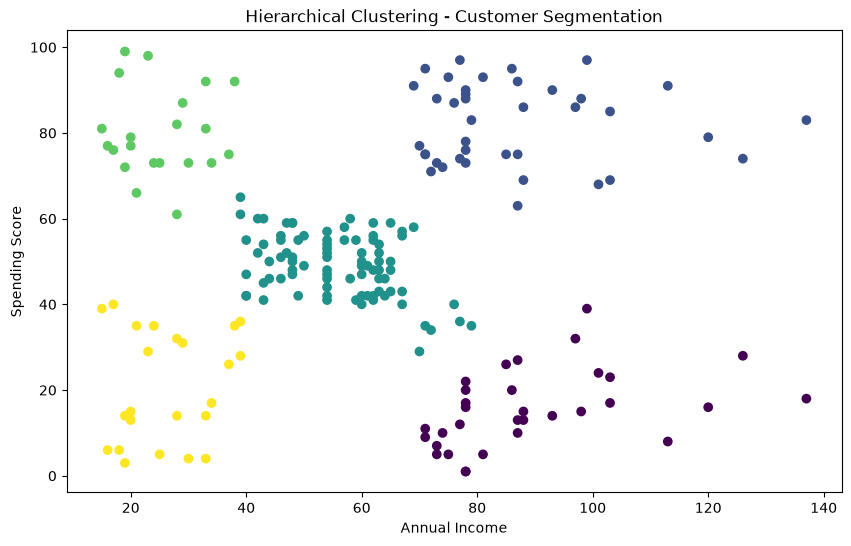

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel('Annual Income')

plt.ylabel('Spending Score')

plt.title('Hierarchical Clustering - Customer Segmentation')

plt.show()

In [18]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)' ,
                                         'Spending Score (1-100)']].mean()
print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 89.406250               15.593750
1                 86.538462               82.128205
2                 55.811765               49.129412
3                 25.095238               80.047619
4                 26.304348               20.913043


In [19]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,1.820000
std,57.879185,13.969007,26.264721,25.823522,1.172379
min,1.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,28.750000,41.500000,34.750000,1.000000
50%,100.500000,36.000000,61.500000,50.000000,2.000000
75%,150.250000,49.000000,78.000000,73.000000,2.000000
max,200.000000,70.000000,137.000000,99.000000,4.000000
